In [2]:
import rebound
import reboundx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import glob
import os

In [3]:
def get_abs(a, b, c):
    return (a**2 + b**2 + c**2)**0.5

def get_v_esc(m1, m2, r1, r2, G):
    v_esc = np.sqrt(2 * G * (m1 + m2)/(r1 + r2))
    return v_esc

In [4]:
base_dir_ias15 = "/Users/honeyeah/Codes/reboundx/ipython_examples/FragmentingCollisions_Diagnostics/embryo_ias15_Jul12"
search_pattern = os.path.join(base_dir_ias15, "embryo_ias15_*")

# List to store each individual DataFrame before combining them
all_ias15_dfs = []

for file_path in glob.glob(search_pattern):
    # Extract the run number from the filename (e.g., "embryo_ias15_8" -> 8)
    filename = os.path.basename(file_path)
    run_number = int(filename.split('_')[-1])
    #print(filename)
    #print(run_number)
    
    archive = rebound.Simulationarchive(file_path)
    G = archive[0].G
    # Initialize lists for this specific archive
    ias15_times = []
    ias15_snapshot_idx = []
    ias15_n_bodies = []
    ias15_masses = []
    ias15_mass_errors = []
    ias15_angular_momentums = []
    ias15_L_rel_errors = []

    # 1. Extract data from each snapshot
    for i in range(len(archive)):
        snap = archive[i]
        ias15_times.append(snap.t)
        ias15_n_bodies.append(snap.N)
        ias15_snapshot_idx.append(i)

        # Calculate angular momentum
        Lx, Ly, Lz = snap.angular_momentum()
        # Assuming get_abs is a custom function you have defined elsewhere, 
        # or you can use np.sqrt(Lx**2 + Ly**2 + Lz**2)
        ias15_angular_momentums.append(get_abs(Lx, Ly, Lz))

        # Calculate total mass
        m = 0
        for j in range(len(snap.particles)):
            m += snap.particles[j].m
        ias15_masses.append(m)

    # 2. Calculate relative mass errors
    for i in range(len(ias15_masses)):
        diff = np.abs((ias15_masses[i] - ias15_masses[0]))
        rel_diff = diff / np.abs(ias15_masses[0])
        ias15_mass_errors.append(rel_diff)

    # 3. Calculate relative angular momentum errors
    for i in range(len(ias15_angular_momentums)):
        diff = np.abs(ias15_angular_momentums[i] - ias15_angular_momentums[0])
        rel_diff = diff / np.abs(ias15_angular_momentums[0])
        ias15_L_rel_errors.append(rel_diff)

    # 4. Create the dictionary for this archive
    ias15_dict = {
        't': ias15_times,
        'N_Bodies': ias15_n_bodies,
        'total_masses': ias15_masses,
        'm_errors': ias15_mass_errors,
        'angular_momentums': ias15_angular_momentums,
        'L_rel_errors': ias15_L_rel_errors,
        'snapshot_idx': ias15_snapshot_idx
    }

    # 5. Convert to DataFrame, add the run number, and append to our master list
    df = pd.DataFrame(ias15_dict)
    df['run_number'] = run_number
    
    all_ias15_dfs.append(df)

# Combine all the individual DataFrames into one large DataFrame
combined_ias15_df = pd.concat(all_ias15_dfs, ignore_index=True)

# View the result
combined_ias15_df.head()

/Users/honeyeah/Codes/rebound/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/Codes/rebound/rebound/simulationarchive.py:103: RuntimeWarning: The binary file seems to be corrupted. An attempt has been made to read the uncorrupted parts of it.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/Codes/rebound/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/Codes/rebound/rebound/simulationarchive.py:103: RuntimeWarning: The binary file seems to be corrupted. An attempt has been made to read the uncorrupted parts of it.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/Codes/rebound/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after cr

,t,N_Bodies,total_masses,m_errors,angular_momentums,L_rel_errors,snapshot_idx,run_number
0,0.000000,31,1.00001,0.0,0.000035,0.000000e+00,0,10
1,10.000526,31,1.00001,0.0,0.000035,1.927590e-16,1,10
2,20.000995,31,1.00001,0.0,0.000035,0.000000e+00,2,10
3,30.000442,31,1.00001,0.0,0.000035,0.000000e+00,3,10
4,40.000009,31,1.00001,0.0,0.000035,1.927590e-16,4,10


In [5]:
base_dir_trace = "/Users/honeyeah/Codes/reboundx/ipython_examples/FragmentingCollisions_Diagnostics/embryo_TRACE_Jul12"
search_pattern = os.path.join(base_dir_trace, "embryo_trace_*")

# List to store each individual DataFrame before combining them
all_trace_dfs = []

for file_path in glob.glob(search_pattern):
    # Extract the run number from the filename (e.g., "embryo_trace_8" -> 8)
    filename = os.path.basename(file_path)
    run_number = int(filename.split('_')[-1])
    archive = rebound.Simulationarchive(file_path)
    
    # Initialize lists for this specific archive
    trace_times = []
    trace_n_bodies = []
    trace_masses = []
    trace_mass_errors = []
    trace_angular_momentums = []
    trace_L_rel_errors = []
    trace_snapshot_idx = []

    # 1. Extract data from each snapshot
    for i in range(len(archive)):
        snap = archive[i]
        trace_times.append(snap.t)
        trace_n_bodies.append(snap.N)
        trace_snapshot_idx.append(i)

        # Calculate angular momentum
        Lx, Ly, Lz = snap.angular_momentum()
        # Assuming get_abs is a custom function you have defined elsewhere, 
        # or you can use np.sqrt(Lx**2 + Ly**2 + Lz**2)
        trace_angular_momentums.append(get_abs(Lx, Ly, Lz))

        # Calculate total mass
        m = 0
        for j in range(len(snap.particles)):
            m += snap.particles[j].m
        trace_masses.append(m)

    # 2. Calculate relative mass errors
    for i in range(len(trace_masses)):
        diff = np.abs((trace_masses[i] - trace_masses[0]))
        rel_diff = diff / np.abs(trace_masses[0])
        trace_mass_errors.append(rel_diff)

    # 3. Calculate relative angular momentum errors
    for i in range(len(trace_angular_momentums)):
        diff = np.abs(trace_angular_momentums[i] - trace_angular_momentums[0])
        rel_diff = diff / np.abs(trace_angular_momentums[0])
        trace_L_rel_errors.append(rel_diff)

    # 4. Create the dictionary for this archive
    trace_dict = {
        't': trace_times,
        'N_Bodies': trace_n_bodies,
        'total_masses': trace_masses,
        'm_errors': trace_mass_errors,
        'angular_momentums': trace_angular_momentums,
        'L_rel_errors': trace_L_rel_errors,
        'snapshot_idx': trace_snapshot_idx
    }

    # 5. Convert to DataFrame, add the run number, and append to our master list
    df = pd.DataFrame(trace_dict)
    df['run_number'] = run_number
    
    all_trace_dfs.append(df)

# Combine all the individual DataFrames into one large DataFrame
combined_trace_df = pd.concat(all_trace_dfs, ignore_index=True)

# View the result
combined_trace_df.head()

/Users/honeyeah/Codes/rebound/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/Codes/rebound/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/Codes/rebound/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/Codes/rebound/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/Codes/rebound/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb

,t,N_Bodies,total_masses,m_errors,angular_momentums,L_rel_errors,snapshot_idx,run_number
0,0.000000,31,1.000008,0.0,0.000026,0.000000e+00,0,2
1,10.010959,31,1.000008,0.0,0.000026,1.967430e-12,1,2
2,20.005479,31,1.000008,0.0,0.000026,4.059508e-12,2,2
3,30.016438,31,1.000008,0.0,0.000026,5.771231e-12,3,2
4,40.010959,31,1.000008,0.0,0.000026,9.594524e-12,4,2


In [6]:
ias15_famtrees = []
base_dir_ias15 = "/Users/honeyeah/Codes/reboundx/ipython_examples/FragmentingCollisions_Diagnostics/embryo_ias15_Jul12/"
search_pattern = os.path.join(base_dir_ias15, "famtree_*")

for file_path in glob.glob(search_pattern):
    filename = os.path.basename(file_path)
    run_number = int(filename.split('_')[-1])
    df = pd.read_csv(file_path,
        header=None, 
        names=[
            "t", "type", "new_id", "parent1_id", "parent2_id",
            "new_mass", "parent1_mass", "parent2_mass", "new_radius",
            "parent1_radius", "parent2_radius", "v_imp", "theta_imp"
        ])
    df['run_number'] = run_number
    ias15_famtrees.append(df)

ias15_famtrees_df = pd.concat(ias15_famtrees, ignore_index=True)

In [8]:
trace_famtrees = []
base_dir_trace = "/Users/honeyeah/Codes/reboundx/ipython_examples/FragmentingCollisions_Diagnostics/embryo_TRACE_Jul12/"
search_pattern = os.path.join(base_dir_trace, "famtree_*")

for file_path in glob.glob(search_pattern):
    filename = os.path.basename(file_path)
    run_number = int(filename.split('_')[-1])
    df = pd.read_csv(file_path,
        header=None, 
        names=[
            "t", "type", "new_id", "parent1_id", "parent2_id",
            "new_mass", "parent1_mass", "parent2_mass", "new_radius",
            "parent1_radius", "parent2_radius", "v_imp", "theta_imp"
        ])
    df['run_number'] = run_number
    trace_famtrees.append(df)

trace_famtrees_df = pd.concat(trace_famtrees, ignore_index=True)

In [9]:
runs_ias15 = combined_ias15_df['run_number'].unique()
runs_ias15

array([10,  4,  3,  2,  5,  7,  9,  8,  6,  1])

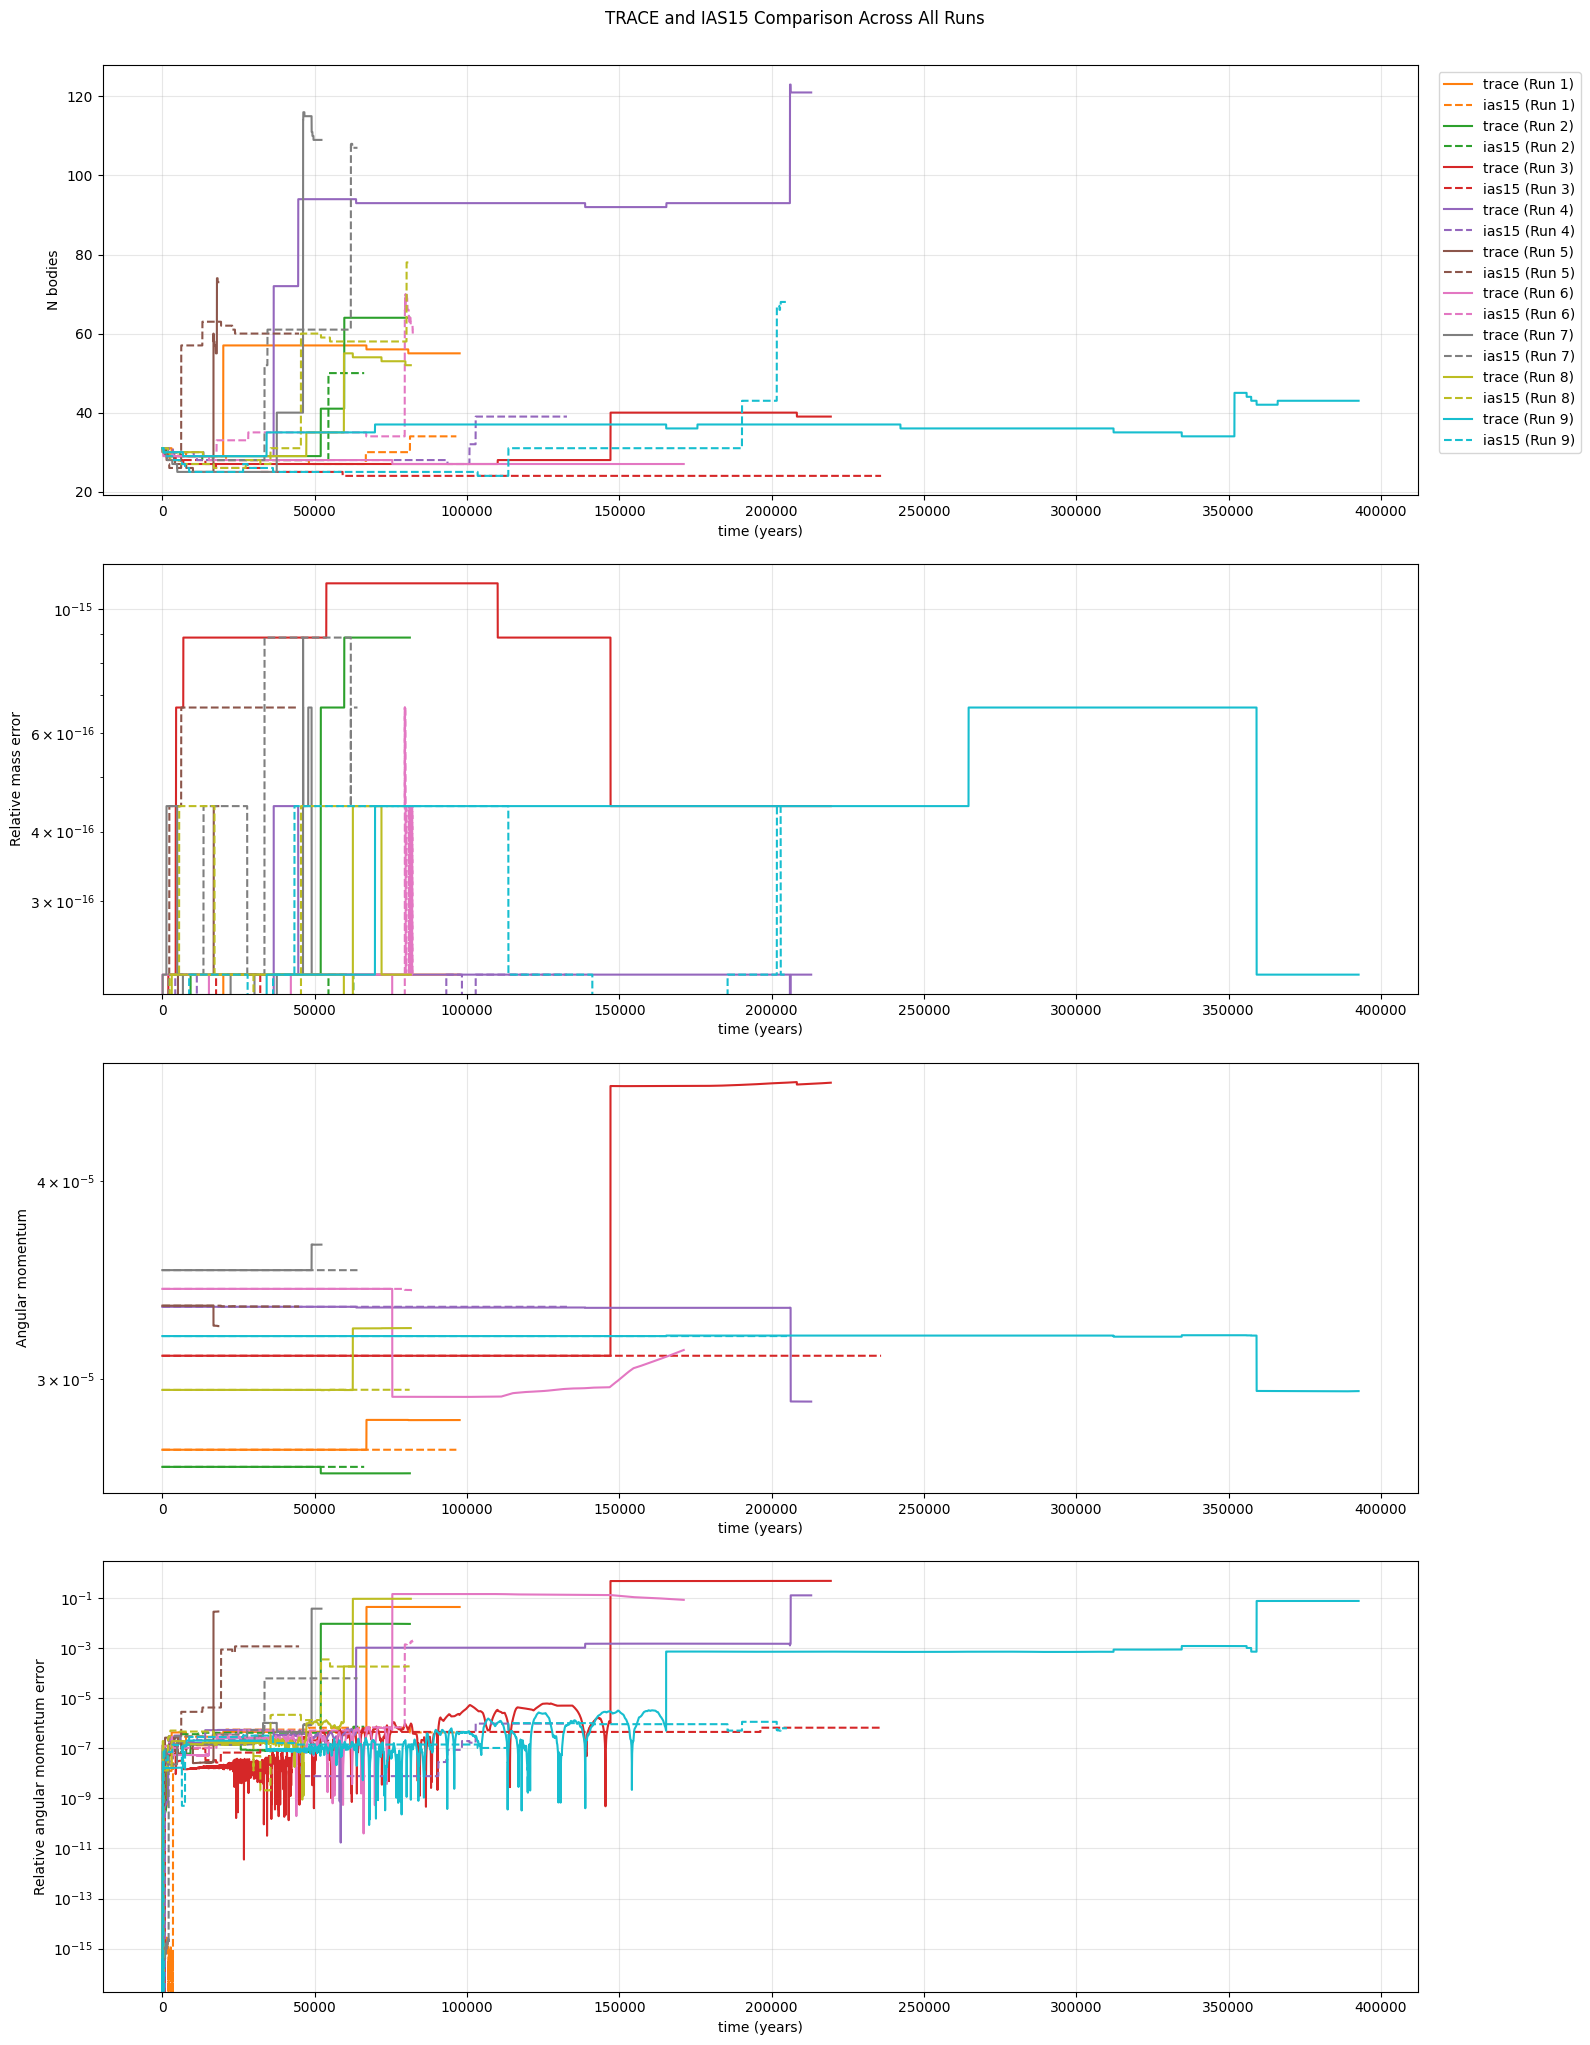

In [10]:
plt.figure(figsize=(16, 20))

# 1. Get unique runs from BOTH dataframes and combine them
runs_ias15 = combined_ias15_df['run_number'].unique()
runs_trace = combined_trace_df['run_number'].unique()

# Generate colors based on the total number of unique runs
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for run in range(10):
    color = colors[run]
    
    # 2. Check and plot Trace data if this run exists in the Trace dataframe
    if run in runs_trace:
        df_tr = combined_trace_df[combined_trace_df['run_number'] == run]
        
        plt.subplot(4, 1, 1)
        plt.plot(df_tr['t'], df_tr['N_Bodies'], color=color, linestyle='-', label=f'trace (Run {run})')
        
        plt.subplot(4, 1, 2)
        plt.plot(df_tr['t'], df_tr['m_errors'], color=color, linestyle='-')
        
        plt.subplot(4, 1, 3)
        plt.plot(df_tr['t'], df_tr['angular_momentums'], color=color, linestyle='-')
        
        plt.subplot(4, 1, 4)
        plt.plot(df_tr['t'], df_tr['L_rel_errors'], color=color, linestyle='-')

    # 3. Check and plot IAS15 data if this run exists in the IAS15 dataframe
    if run in runs_ias15:
        df_ias = combined_ias15_df[combined_ias15_df['run_number'] == run]
        
        plt.subplot(4, 1, 1)
        plt.plot(df_ias['t'], df_ias['N_Bodies'], color=color, linestyle='--', label=f'ias15 (Run {run})')
        
        plt.subplot(4, 1, 2)
        plt.plot(df_ias['t'], df_ias['m_errors'], color=color, linestyle='--')
        
        plt.subplot(4, 1, 3)
        plt.plot(df_ias['t'], df_ias['angular_momentums'], color=color, linestyle='--')
        
        plt.subplot(4, 1, 4)
        plt.plot(df_ias['t'], df_ias['L_rel_errors'], color=color, linestyle='--')


# Format Subplot 1
plt.subplot(4, 1, 1)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xlabel("time (years)")
plt.ylabel("N bodies")

# Format Subplot 2
plt.subplot(4, 1, 2)
plt.grid(True, alpha=0.3)
plt.xlabel("time (years)")
plt.ylabel("Relative mass error")
plt.yscale("log")

# Format Subplot 3
plt.subplot(4, 1, 3)
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.xlabel("time (years)")
plt.ylabel("Angular momentum")

# Format Subplot 4
plt.subplot(4, 1, 4)
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.xlabel("time (years)")
plt.ylabel("Relative angular momentum error")

plt.tight_layout()
plt.suptitle("TRACE and IAS15 Comparison Across All Runs", y=1.02)
plt.show()

# TRACE 1

In [11]:
run = 1
df_tr = combined_trace_df[combined_trace_df['run_number'] == run]

coll_indxs = []
coll_times = []
for i in range(len(df_tr)-1):
    if (df_tr['L_rel_errors'].iloc[i+1] - df_tr['L_rel_errors'].iloc[i]) > 1e-3:
        coll_indxs.append(df_tr['snapshot_idx'].iloc[i])
        coll_times.append(df_tr['t'].iloc[i])

In [12]:
famtree_1 = trace_famtrees_df[trace_famtrees_df['run_number'] == 1]
coll_1_run_1 = famtree_1[(famtree_1['t'] < coll_times[0] + 10) & (famtree_1['t'] > coll_times[0] - 10)]
coll_1_run_1

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp,run_number
783,66974.84,3,93,61,0,1.0,1.445570e-08,1.0,0.00465,0.000009,0.00465,130.5294,1.474511,1


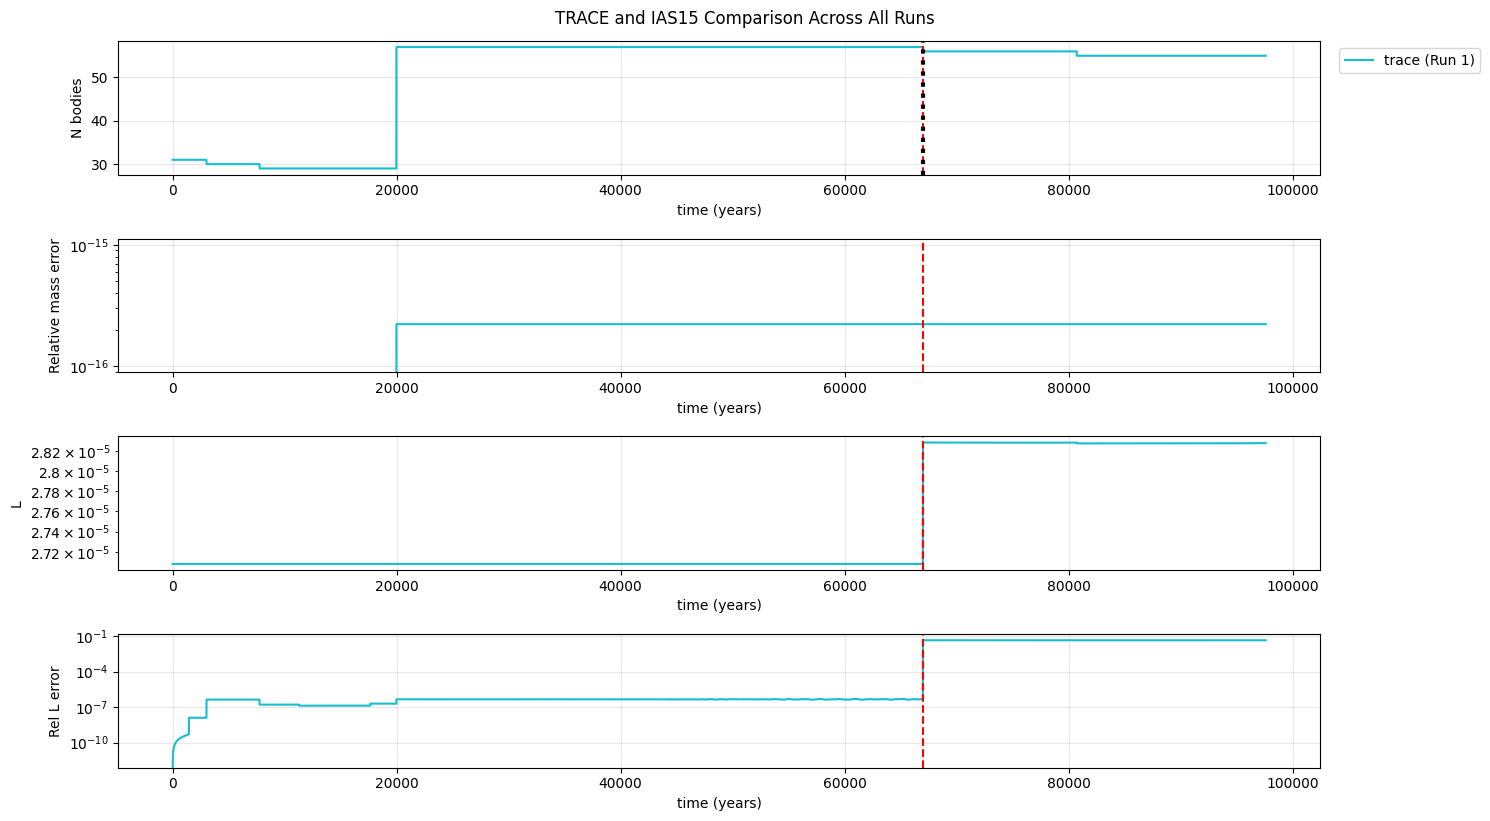

In [13]:
plt.figure(figsize=(15, 8))

# Format Subplot 1
plt.subplot(4, 1, 1)
plt.plot(df_tr['t'], df_tr['N_Bodies'], color=color, linestyle='-', label=f'trace (Run {run})')
for i in range(len(coll_times)):
    plt.axvline(coll_times[i], color = 'red', linestyle = '--')
    plt.axvline(coll_1_run_1['t'].iloc[0], color = 'black', linestyle = ':', linewidth = 3)

plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xlabel("time (years)")
plt.ylabel("N bodies")

# Format Subplot 2
plt.subplot(4, 1, 2)
plt.plot(df_tr['t'], df_tr['m_errors'], color=color, linestyle='-')
for i in range(len(coll_times)):
    plt.axvline(coll_times[i], color = 'red', linestyle = '--')

plt.grid(True, alpha=0.3)
plt.xlabel("time (years)")
plt.ylabel("Relative mass error")
plt.yscale("log")

# Format Subplot 3
plt.subplot(4, 1, 3)
plt.plot(df_tr['t'], df_tr['angular_momentums'], color=color, linestyle='-')
for i in range(len(coll_times)):
    plt.axvline(coll_times[i], color = 'red', linestyle = '--')

plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.xlabel("time (years)")
plt.ylabel("L")


# Format Subplot 4
plt.subplot(4, 1, 4)
plt.plot(df_tr['t'], df_tr['L_rel_errors'], color=color, linestyle='-')
for i in range(len(coll_times)):
    plt.axvline(coll_times[i], color = 'red', linestyle = '--')

plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.xlabel("time (years)")
plt.ylabel("Rel L error")

plt.tight_layout()
plt.suptitle("TRACE and IAS15 Comparison Across All Runs", y=1.02)
plt.show()

In [14]:
coll_1_run_1

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp,run_number
783,66974.84,3,93,61,0,1.0,1.445570e-08,1.0,0.00465,0.000009,0.00465,130.5294,1.474511,1


In [15]:
coll_indxs

[np.int64(6697)]

In [16]:
coll_times

[np.float64(66970.01095801467)]

In [17]:
print(rebound.__version__)
print(rebound.__githash__)

4.4.10
3924dfd13a3501acddc0b24f6c06165e85bbae96


# TRACE 2

In [18]:
run = 2
df_tr = combined_trace_df[combined_trace_df['run_number'] == run]

coll_indxs = []
coll_times = []
for i in range(len(df_tr)-1):
    if (df_tr['L_rel_errors'].iloc[i+1] - df_tr['L_rel_errors'].iloc[i]) > 1e-3:
        coll_indxs.append(df_tr['snapshot_idx'].iloc[i])
        coll_times.append(df_tr['t'].iloc[i])

In [19]:
famtree_2 = trace_famtrees_df[trace_famtrees_df['run_number'] == 2]
coll_1_run_2 = famtree_2[(famtree_2['t'] < coll_times[0] + 10) & (famtree_2['t'] > coll_times[0] - 10)]
coll_1_run_2

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp,run_number
283,51987.89,6,50,48,1,1.400000e-08,1.213534e-07,9.232531e-08,0.000009,0.000018,0.000016,3.868404,0.862533,2
284,51987.89,6,51,48,1,1.422489e-08,1.213534e-07,9.232531e-08,0.000009,0.000018,0.000016,3.868404,0.862533,2
285,51987.89,6,52,48,1,1.419524e-08,1.213534e-07,9.232531e-08,0.000009,0.000018,0.000016,3.868404,0.862533,2
286,51987.89,6,53,48,1,1.427548e-08,1.213534e-07,9.232531e-08,0.000009,0.000018,0.000016,3.868404,0.862533,2
287,51987.89,6,54,48,1,1.428069e-08,1.213534e-07,9.232531e-08,0.000009,0.000018,0.000016,3.868404,0.862533,2
288,51987.89,6,55,48,1,1.423833e-08,1.213534e-07,9.232531e-08,0.000009,0.000018,0.000016,3.868404,0.862533,2
289,51987.89,6,56,48,1,1.427827e-08,1.213534e-07,9.232531e-08,0.000009,0.000018,0.000016,3.868404,0.862533,2
290,51987.89,6,57,48,1,1.427338e-08,1.213534e-07,9.232531e-08,0.000009,0.000018,0.000016,3.868404,0.862533,2
291,51987.89,6,58,48,1,1.428457e-08,1.213534e-07,9.232531e-08,0.000009,0.000018,0.000016,3.868404,0.862533,2
292,51987.89,6,59,48,1,1.426951e-08,1.213534e-07,9.232531e-08,0.000009,0.000018,0.000016,3.868404,0.862533,2


In [20]:
coll_indxs

[np.int64(5198)]

In [6]:
def get_previous_snapshot_index(collision_time, dt, steps_per_snapshot):
    time_between_snapshots = dt * steps_per_snapshot
    
    # Calculate the integer index of the snapshot
    index = int(collision_time / time_between_snapshots)
    
    # Ensure the snapshot time is strictly before the collision time
    if (index * time_between_snapshots) >= collision_time:
        index = index - 1
        
    # Prevent a negative index if the collision happens immediately
    if index < 0:
        index = 0
        
    return index

# Example usage:
collision_time = 4.483203e+03
dt = 6.0 / 365.0
steps_per_snapshot = 50

snapshot_to_load = get_previous_snapshot_index(collision_time, dt, steps_per_snapshot)
print(f"Loading snapshot index: {snapshot_to_load}")

Loading snapshot index: 5454


In [7]:
#ias15_3_det_step
snapshot_to_load = get_previous_snapshot_index(collision_time=8.318553e+01, dt=(6.0 / 365.0), steps_per_snapshot=50)
print(f"Loading snapshot index: {snapshot_to_load}")

Loading snapshot index: 101


In [8]:
83 / (6/365)

5049.166666666667

In [9]:
5049/50

100.98